Sunday 21 June
This is in response to Gabe's feedback on Friday.
I've already run alignments for RS, CUT3R and then today did mega sam. But will do more for good comparisons. Taking cells from MASTER SWITCH

In [2]:
%load_ext autoreload
%autoreload 2

In [7]:
from pathlib import Path
import sys

project_root = Path.cwd().parent      # up from experiments/ to MScPROJECT_LOCAL
sys.path.insert(0, str(project_root / "src"))   # down into src/
from B_align_traces import load_reality_scan_trace, load_VGGT_O_trace
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align

In [5]:



case_name = "01_walk"
case_dir     = project_root / "Data" / case_name
out_dir     =   project_root / "Data" / case_name / "080_Experiments"

INITIAL 50 RESULTS FROM WALK_01 - low res images


In [ ]:
#CUT3R vs MegaSam
import importlib, sys
sys.path.insert(0, str(project_root / "src"))

import B_align_traces; importlib.reload(B_align_traces)


A = load_cut3r_trace(case_dir / "035_CUT3R_output" / "21" / "camera")
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / f"{case_name}_sgd_cvd_hr_01.npz")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, B, "CUT3R","MegaSAM", out_path =out_dir/"Initial_050_C_M.png" , anchor_index=0)
print("RMSE after alignment:", rmse)

In [ ]:
#COMPARE CAMERA SOLVES RS vs MEGASCAN
import sys
sys.path.insert(0, str(project_root / "src"))
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align, load_reality_scan_trace

Reality_scan = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05b.csv")
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / f"{case_name}_sgd_cvd_hr_01.npz")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(Reality_scan, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"Initial_050_RS_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

In [ ]:
#COMPARE CAMERA SOLVES RS vs CUT3R
import sys
sys.path.insert(0, str(project_root / "src"))
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align, load_reality_scan_trace

Reality_scan = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05b.csv")
C = load_cut3r_trace(case_dir / "035_CUT3R_output" / "21" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(Reality_scan, C, "Reality_scan" , "CUT3R" , out_path =out_dir/"Initial_050_RS_C.png"  , anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

22/06 - moved onto full res for rc and it works much better, so now for the comparisons

In [ ]:
#RCfull vs RC 512
import importlib, sys
sys.path.insert(0, str(project_root / "src"))

import B_align_traces; importlib.reload(B_align_traces)
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align

A = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_FULL.csv")
B = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_initial_50_05e.csv")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, B, "FULL_res","downscale", out_path =out_dir/"Initial_050_RC_RC.png" , anchor_index=0,skip_indices=(31,44))
print("RMSE after alignment:", rmse)

OK, after explorintg RC, 1 frame every 25 fames is working well - about 1s interval there.


RMSE after alignment: 1.0460606602160023


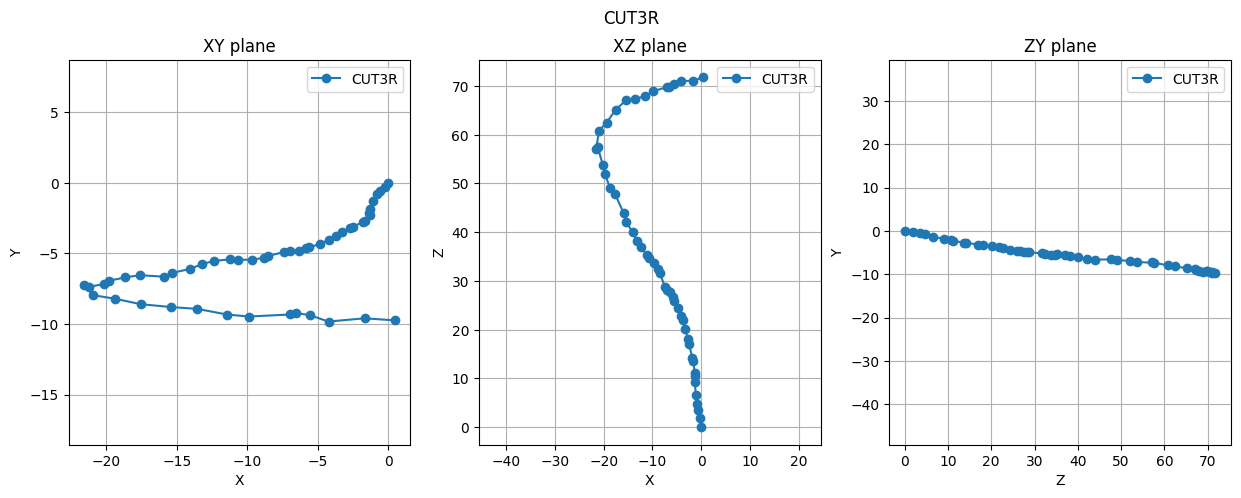

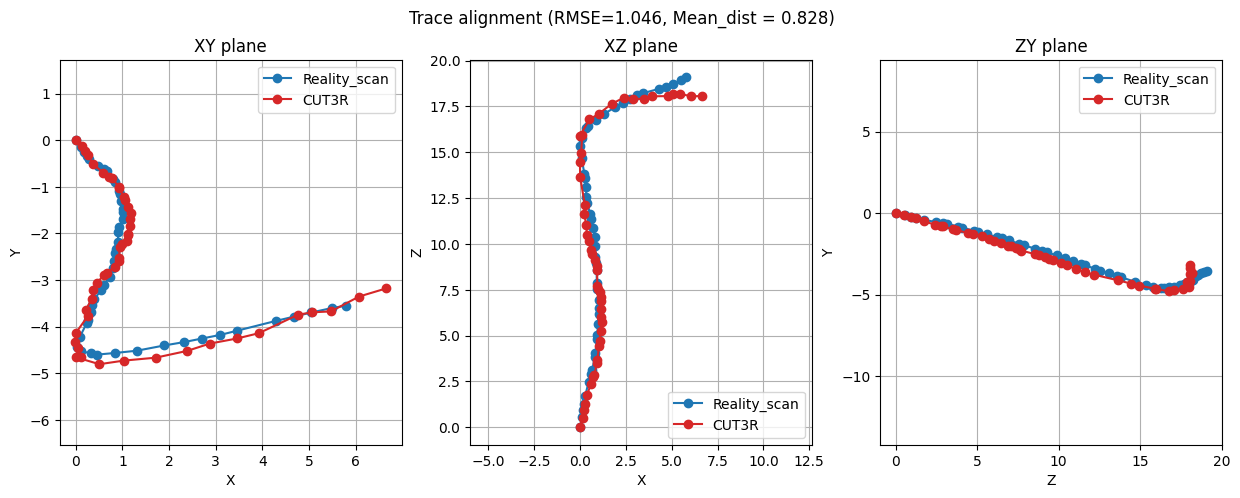

In [23]:
#COMPARE CAMERA SOLVES RS vs CUT3R
import sys
sys.path.insert(0, str(project_root / "src"))
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align, load_reality_scan_trace


B = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS, B, "Reality_scan" , "CUT3R" , out_path =out_dir/"01_walk_sparse_50_02_RS_C.png"  , anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

RMSE after alignment: 3.522059029101574


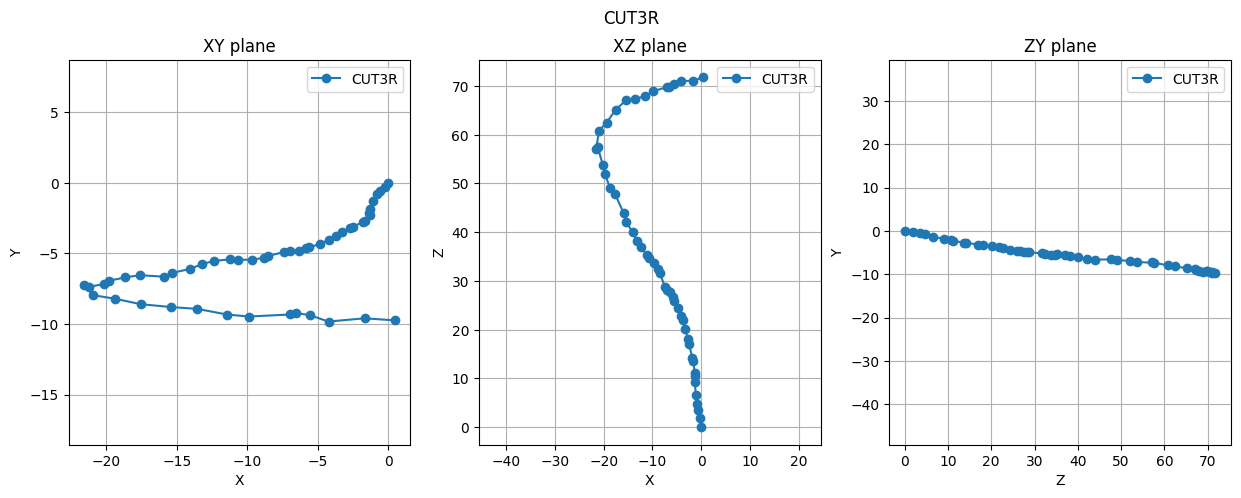

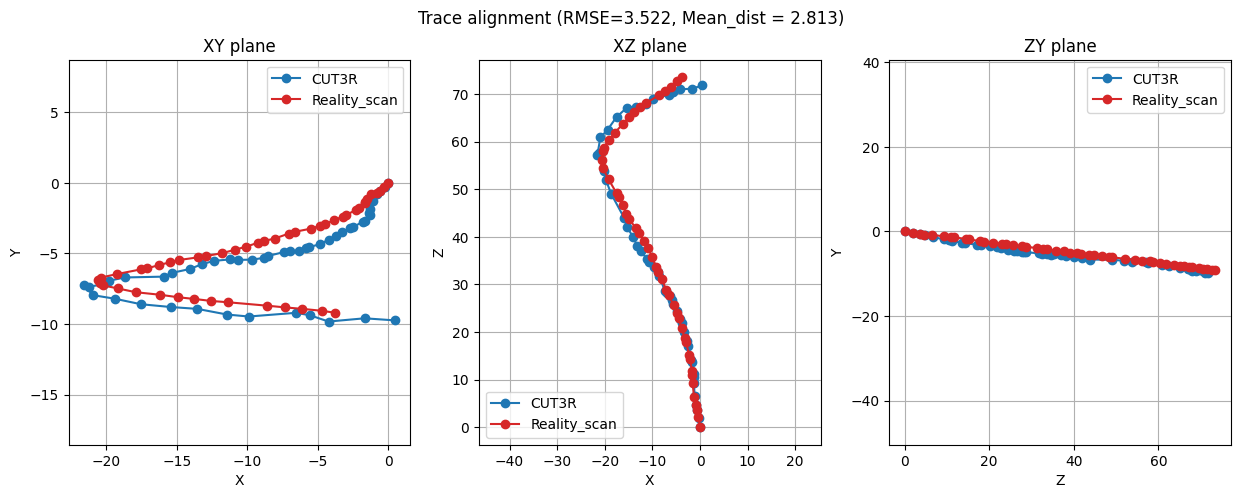

In [21]:
#COMPARE CAMERA SOLVES CUT3R vs RS 
import sys
sys.path.insert(0, str(project_root / "src"))
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align, load_reality_scan_trace


A = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")

assert A.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(A, RS, "CUT3R", "Reality_scan"  , out_path =out_dir/"01_walk_sparse_50_02_RS_C.png"  , anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

RMSE after alignment: 1.51649402391228


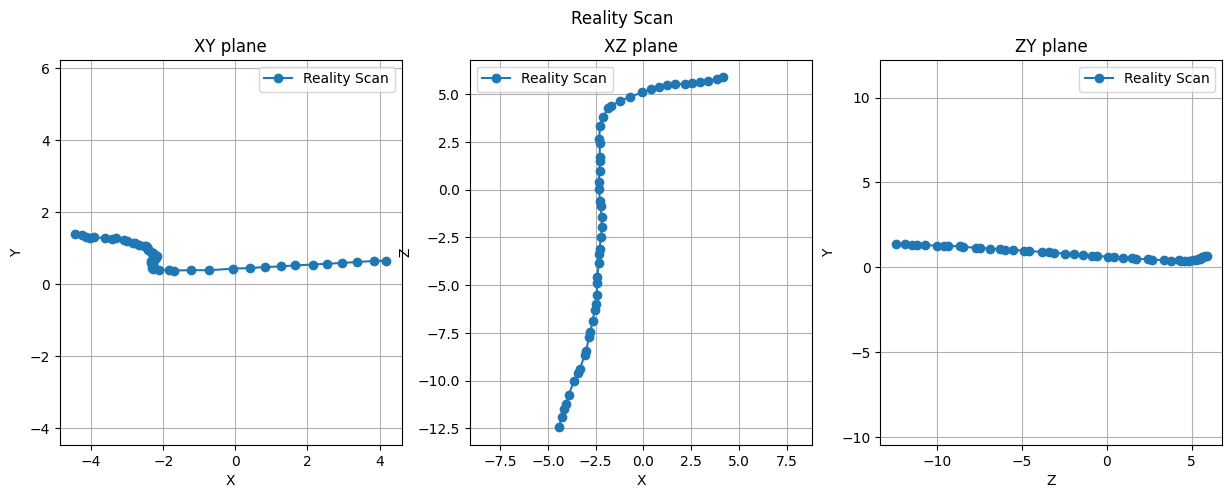

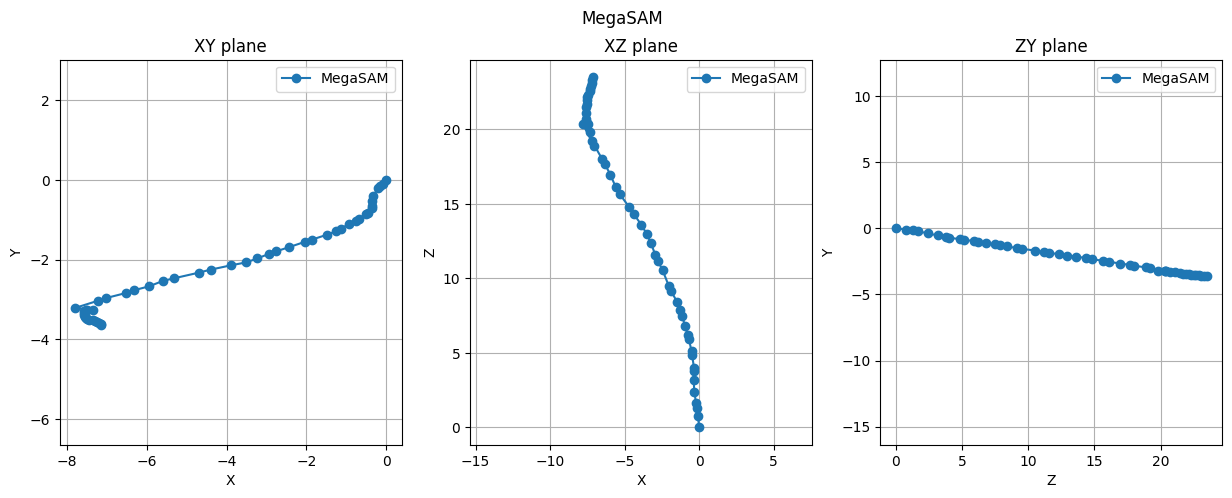

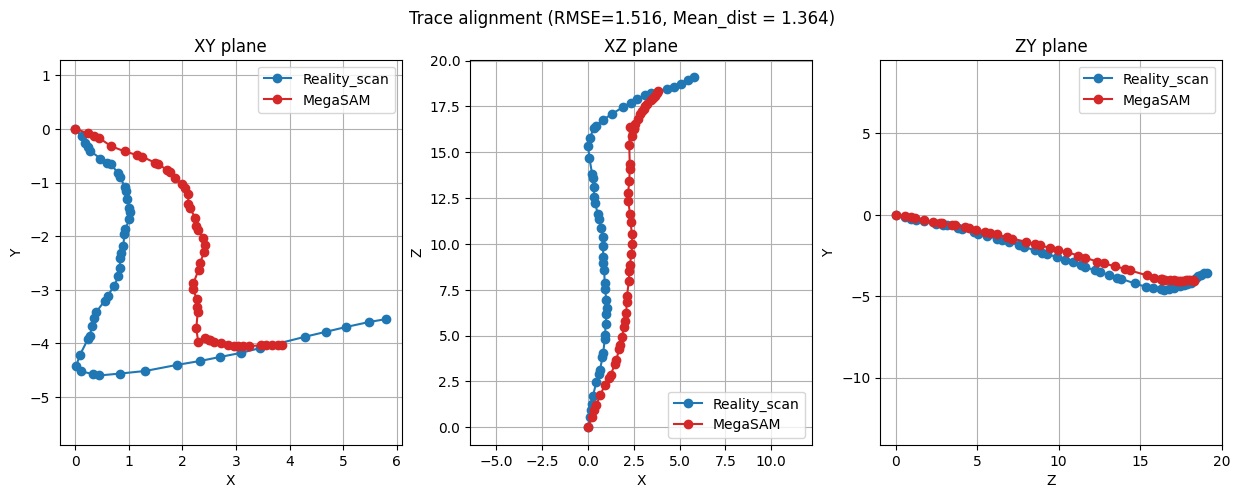

In [18]:
#COMPARE CAMERA SOLVES RS vs MEGASCAN
import sys
sys.path.insert(0, str(project_root / "src"))
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align, load_reality_scan_trace

RS = load_reality_scan_trace(case_dir / "030_Registrations"/"Registration_reality_scan" /"01_walk_sparse_50_02_full_02" /"01_walk_sparse_50_02_FULL_02.csv")
B = load_megasam_trace(case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full" / f"{case_name}_sgd_cvd_hr.npz")

assert RS.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(RS, B, "Reality_scan" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

RMSE after alignment: 6.706211312793701


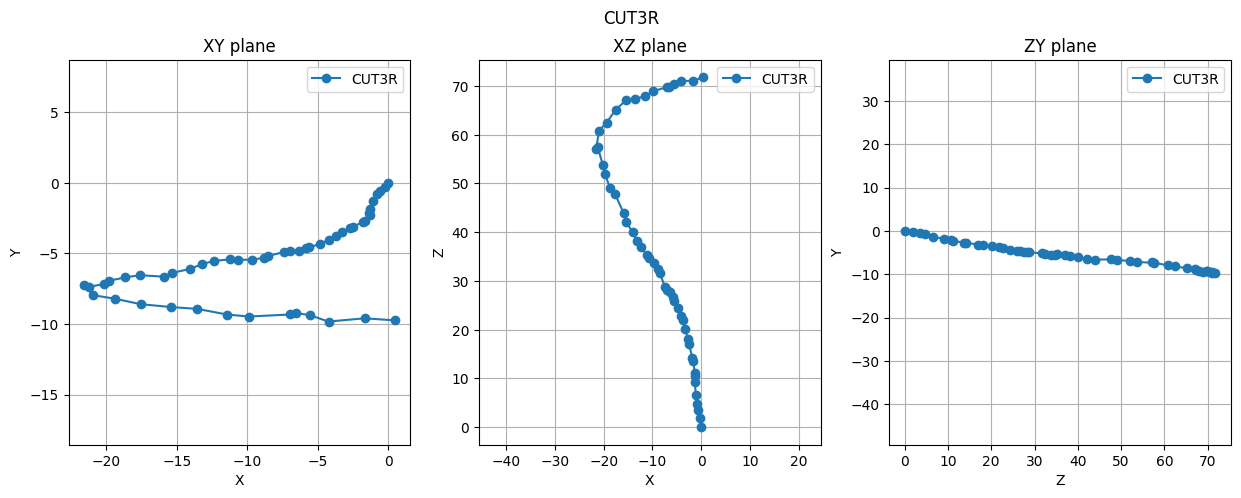

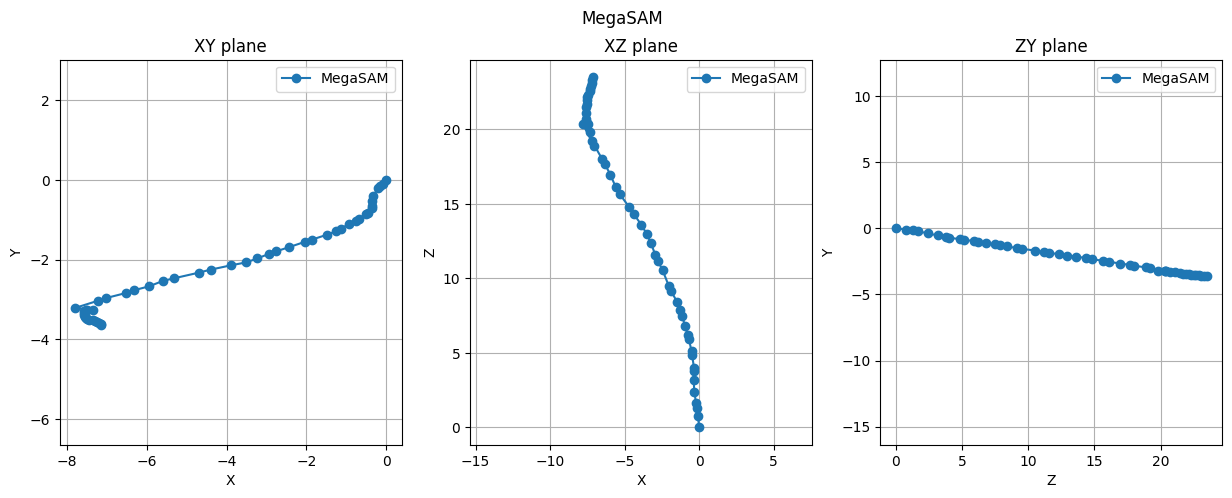

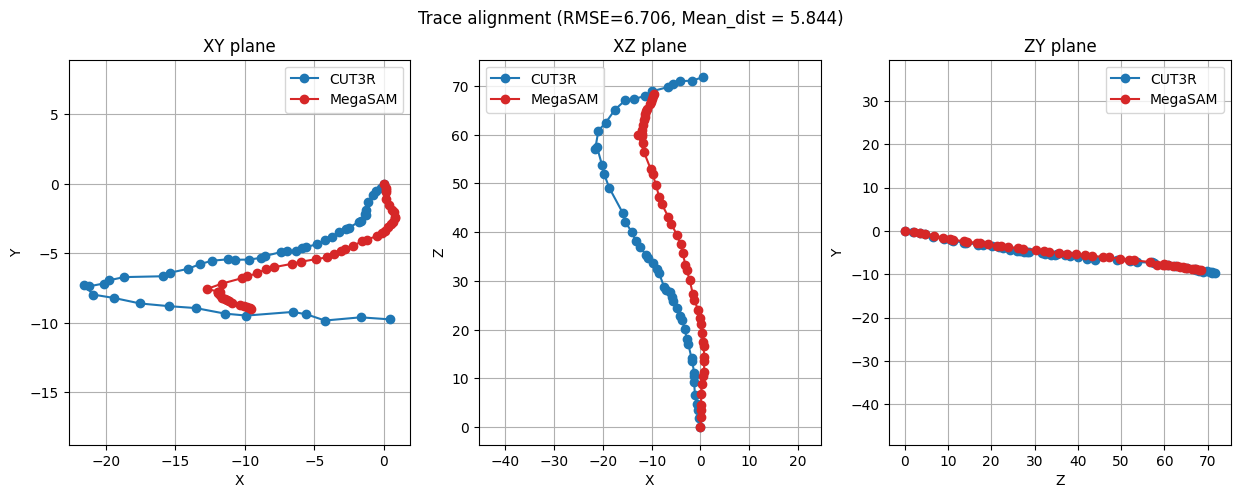

In [19]:
#COMPARE CAMERA SOLVES CUT3R vs MEGASCAN
import sys
sys.path.insert(0, str(project_root / "src"))
from B_align_traces import load_cut3r_trace, load_megasam_trace, umeyama_align, load_reality_scan_trace

CUT = load_cut3r_trace(case_dir / "035_CUT3R_output" / "01_walk_sparse_50_02_full" / "camera")
M = load_megasam_trace(case_dir / "036_MEGASAM_output" / "01_walk_sparse_50_02_full" / f"{case_name}_sgd_cvd_hr.npz")

assert CUT.shape == B.shape, f"Mismatched trace lengths: A={A.shape}, B={B.shape}"

R, s, t, B_aligned, rmse = umeyama_align(CUT, M, "CUT3R" , "MegaSAM" ,  out_path =out_dir/"01_walk_sparse_50_02_full_C_M.png" ,anchor_index=0, skip_indices=(31,44))
print("RMSE after alignment:", rmse)

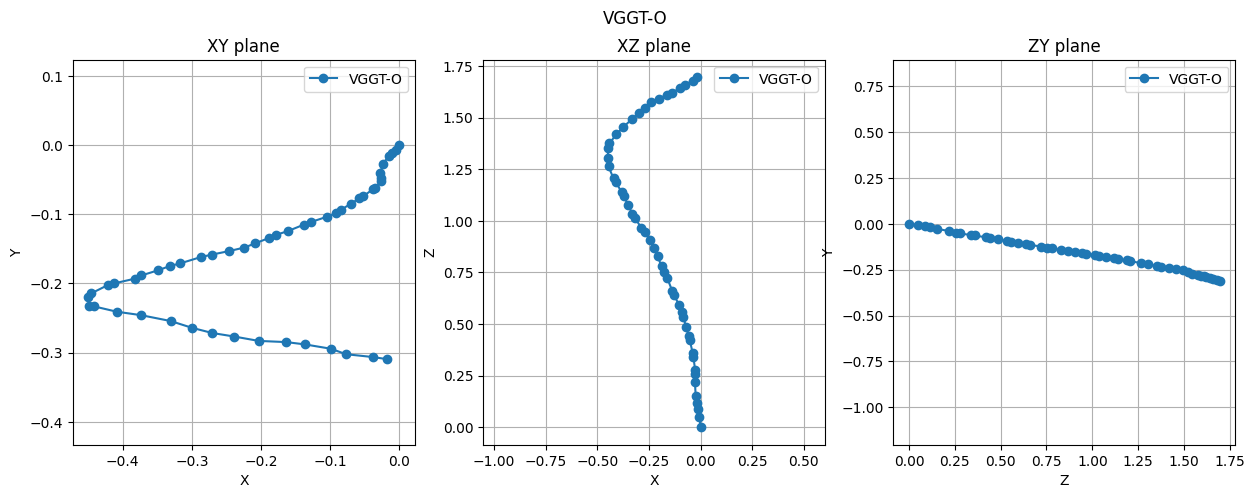

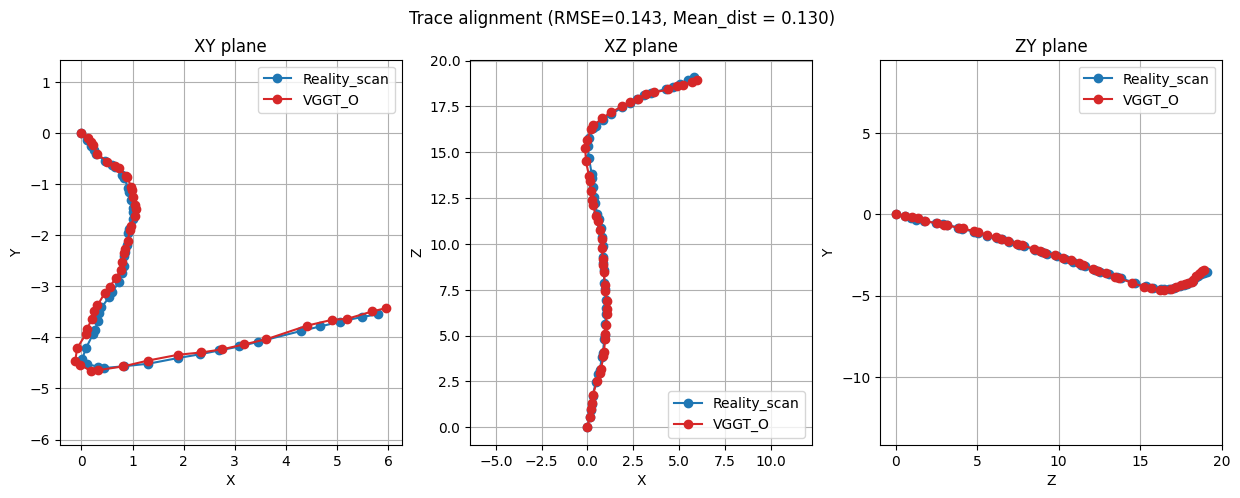

In [24]:
VGGTO = load_VGGT_O_trace((case_dir / "035_VGGT_O_output" / "01_walk_sparse_50_02_full" / "predictions.npz"))
R, s, t, B_aligned, rmse = umeyama_align(RS,VGGTO , "Reality_scan" , "VGGT_O" ,  out_path =out_dir/"01_walk_sparse_50_02_full_RS_VGGTO.png" ,anchor_index=0, skip_indices=(31,44))